In [1]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('/content/House_Price_Prediction_Dataset_a2sttc.csv')

In [4]:
df.shape

(2000, 10)

In [5]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [6]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [8]:
print("Available columns in your DataFrame:", df.columns.tolist())


Available columns in your DataFrame: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


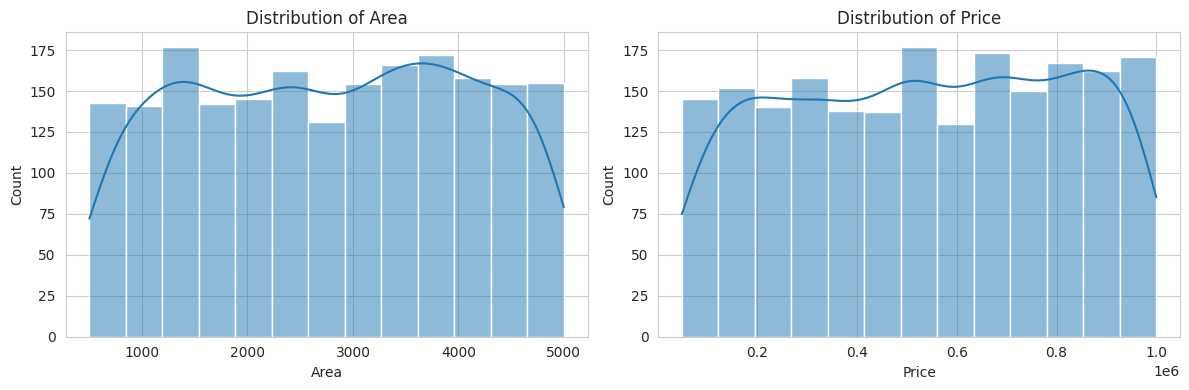

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(data=df, x='Area', kde=True, ax=ax[0])
ax[0].set_title('Distribution of Area')
sns.histplot(data=df, x='Price', kde=True, ax=ax[1])
ax[1].set_title('Distribution of Price')
plt.tight_layout()
plt.show()

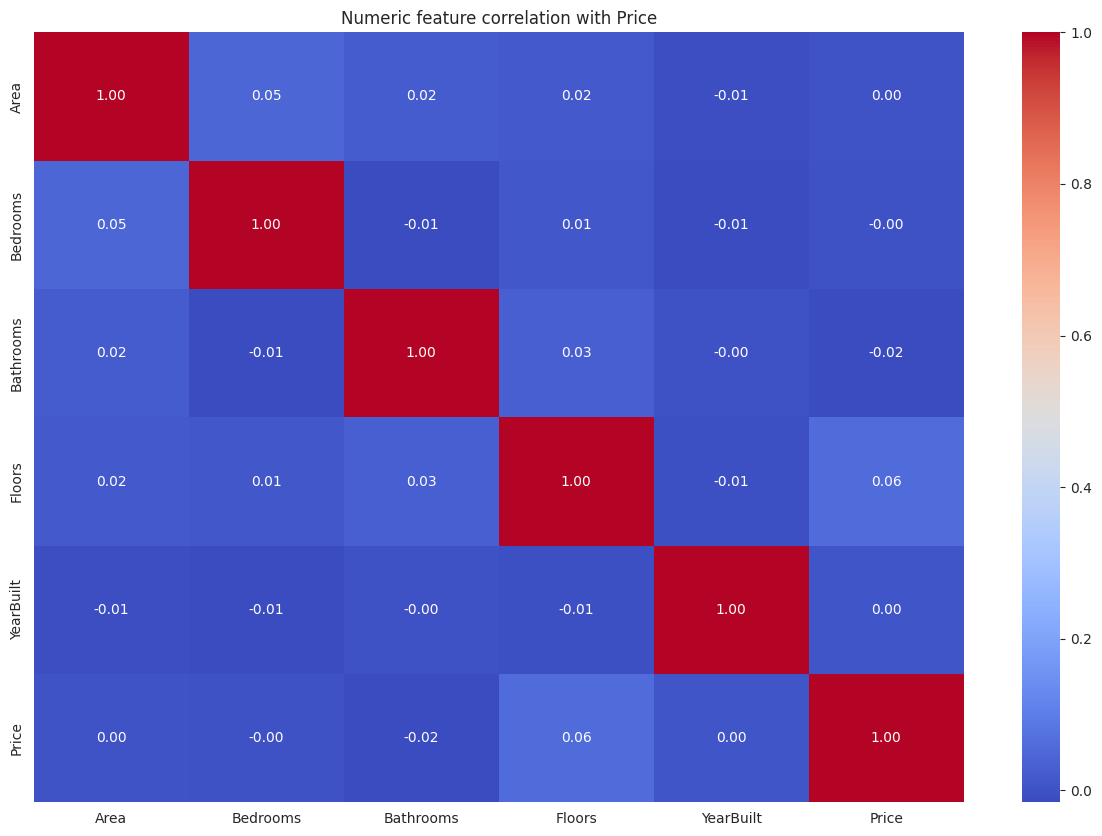

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Id' as it's just an identifier, and 'Price' will be the target variable
features = [col for col in numeric_cols if col not in ['Id', 'Price']]

plt.figure(figsize=(15,10))
sns.heatmap(df[features + ['Price']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric feature correlation with Price')
plt.show()

In [14]:
# Drop 'Id' column as it's an identifier
df_processed = df.drop(columns=['Id'])

# Handle categorical features using one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# Define features (X) and target (y)
X = df_processed.drop(columns=['Price'])
y = df_processed['Price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (1600, 12)  Test: (400, 12)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train a Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test)

# Evaluate the model
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print(f"Linear Regression MAE: {mae_lin_reg:.2f}")
print(f"Linear Regression MSE: {mse_lin_reg:.2f}")
print(f"Linear Regression R-squared: {r2_lin_reg:.4f}")

Linear Regression MAE: 243241.98
Linear Regression MSE: 78321466146.03
Linear Regression R-squared: -0.0067


In [21]:
# Feature Importance for Linear Regression

feature_importance_lin_reg = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lin_reg_model.coef_
})

# Sort by absolute importance
feature_importance_lin_reg['Absolute_Coefficient'] = abs(
    feature_importance_lin_reg['Coefficient']
)

feature_importance_lin_reg = feature_importance_lin_reg.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(feature_importance_lin_reg)


              Feature   Coefficient  Absolute_Coefficient
8      Condition_Fair  24083.307846          24083.307846
3              Floors  23727.983633          23727.983633
9      Condition_Good -12941.044835          12941.044835
7      Location_Urban -12718.918912          12718.918912
6   Location_Suburban  11511.989815          11511.989815
2           Bathrooms  -9662.248234           9662.248234
10     Condition_Poor   4073.268930           4073.268930
11         Garage_Yes   2373.530579           2373.530579
5      Location_Rural   1317.542020           1317.542020
4           YearBuilt    117.613885            117.613885
1            Bedrooms     76.784827             76.784827
0                Area     -0.575754              0.575754


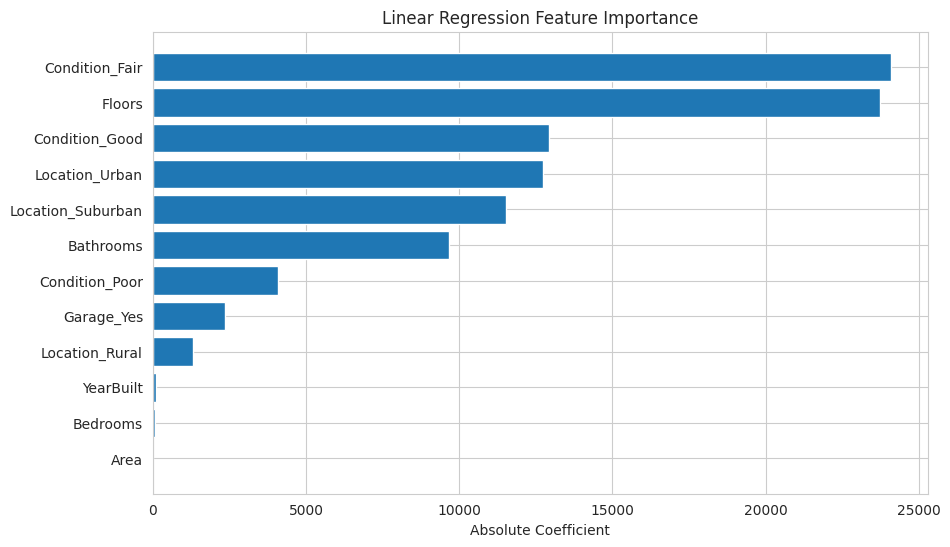

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_lin_reg['Feature'],
    feature_importance_lin_reg['Absolute_Coefficient']
)

plt.title("Linear Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest R-squared: {r2_rf:.4f}")

Random Forest MAE: 247761.03
Random Forest MSE: 81437468814.83
Random Forest R-squared: -0.0468


In [26]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,Area,0.345215
4,YearBuilt,0.261638
1,Bedrooms,0.088920
2,Bathrooms,0.070596
3,Floors,0.049540
11,Garage_Yes,0.029562
8,Condition_Fair,0.027505
7,Location_Urban,0.027302
5,Location_Rural,0.027205
6,Location_Suburban,0.024572


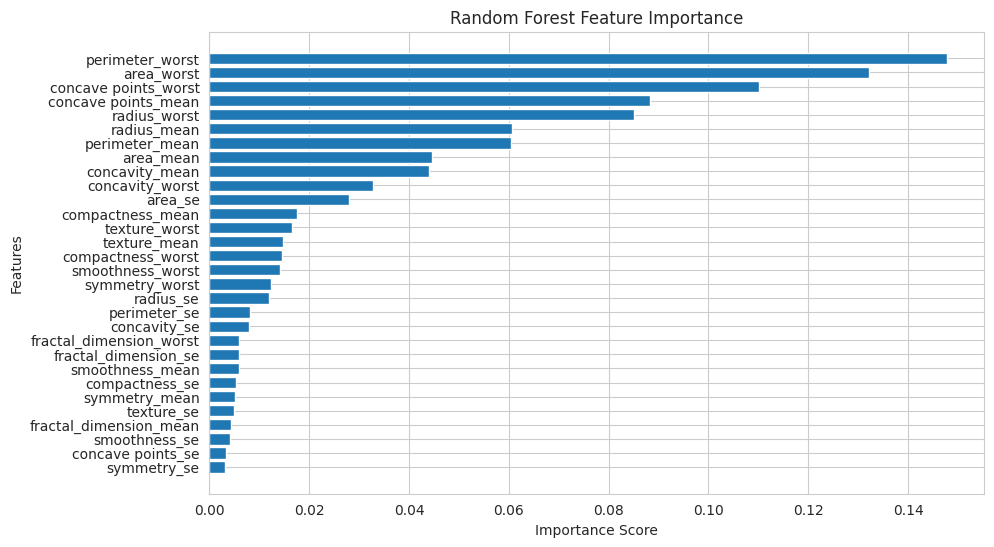

In [ ]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf['Feature'],
    feature_importance_rf['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.2f}")
print(f"XGBoost MSE: {mse_xgb:.2f}")
print(f"XGBoost R-squared: {r2_xgb:.4f}")

XGBoost MAE: 254614.88
XGBoost MSE: 86670041088.00
XGBoost R-squared: -0.1140


In [28]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_xgb

,Feature,Importance
6,Location_Suburban,0.097795
8,Condition_Fair,0.091808
4,YearBuilt,0.091748
7,Location_Urban,0.089755
5,Location_Rural,0.084955
2,Bathrooms,0.084044
11,Garage_Yes,0.083570
0,Area,0.081971
1,Bedrooms,0.077188
10,Condition_Poor,0.074591


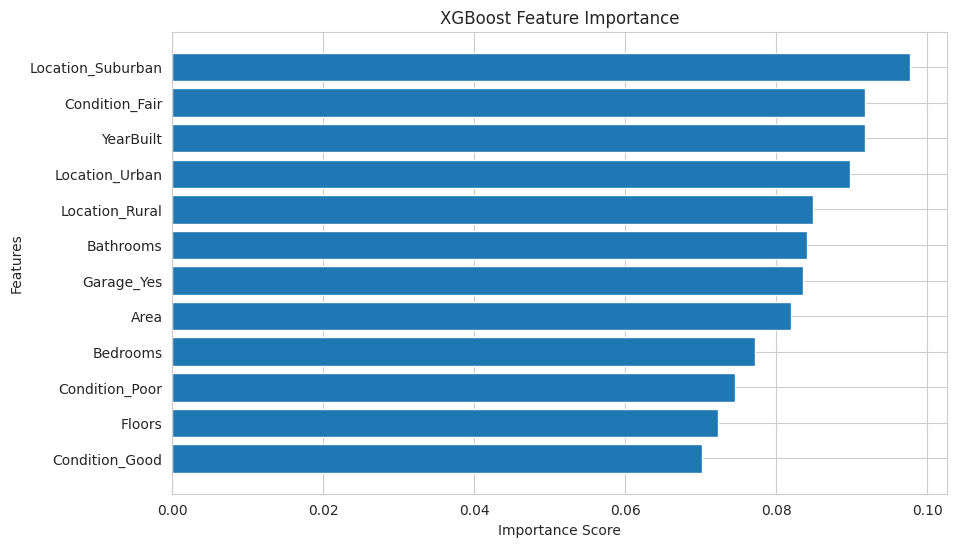

In [38]:


feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'],
    feature_importance_xgb['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [29]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae_lin_reg,
        mae_rf,
        mae_xgb
    ],
    'MSE': [
        mse_lin_reg,
        mse_rf,
        mse_xgb
    ],
    'R-squared': [
        r2_lin_reg,
        r2_rf,
        r2_xgb
    ]
})

comparison.sort_values(
    by='R-squared',
    ascending=False
)

,Model,MAE,MSE,R-squared
0,Linear Regression,243241.977588,7.832147e+10,-0.006718
1,Random Forest,247761.029870,8.143747e+10,-0.046770
2,XGBoost,254614.875000,8.667004e+10,-0.114028


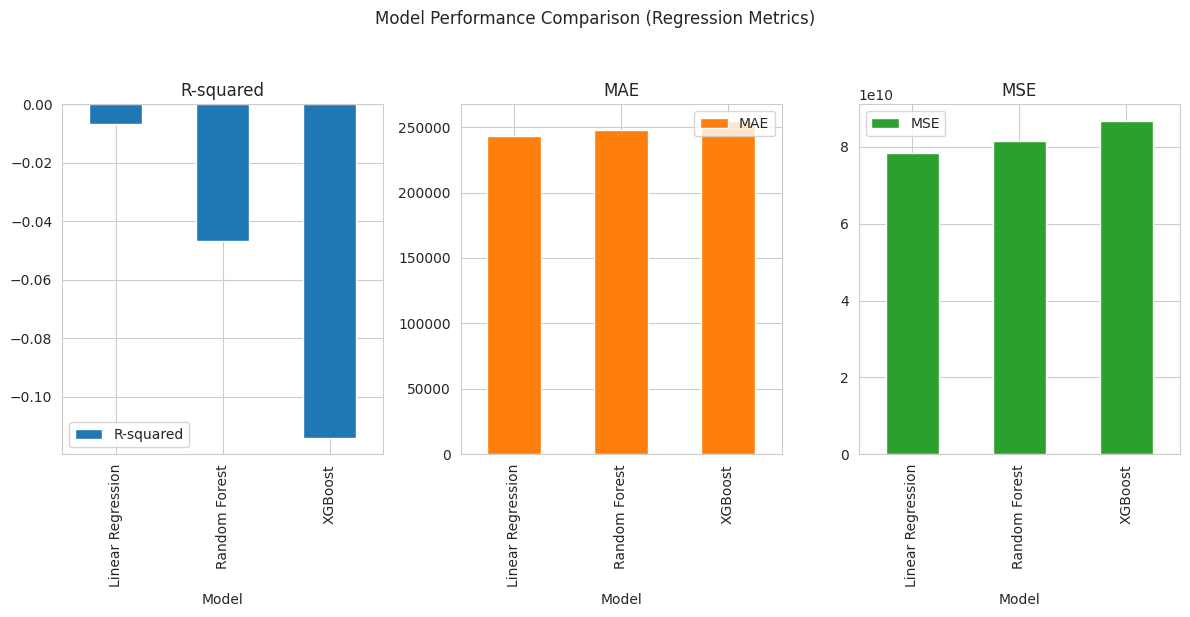

In [31]:
comparison.set_index('Model')[['R-squared', 'MAE', 'MSE']].plot(
    kind='bar',
    figsize=(12,6),
    subplots=True,
    layout=(1,3)
)

plt.suptitle("Model Performance Comparison (Regression Metrics)", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [33]:
best_model_name = comparison.sort_values(
    by='R-squared',
    ascending=False
).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [34]:
import joblib

if best_model_name == "Linear Regression":
    best_model = lin_reg_model
elif best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "XGBoost":
    best_model = xgb_model
else:
    # Fallback or error handling if best_model_name is unexpected
    print(f"Warning: Unexpected best_model_name: {best_model_name}. Defaulting to Linear Regression.")
    best_model = lin_reg_model

joblib.dump(best_model, "house_price_model.pkl")

print("Best model saved successfully as house_price_model.pkl!")

Best model saved successfully as house_price_model.pkl!


In [36]:
app_py_content = """
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title="House Price Prediction",
    page_icon="🏠",
    layout="wide"
)

# LOAD MODEL

model = joblib.load('house_price_model.pkl') # Model saved with this name previously

# CUSTOM CSS

st.markdown('''
<style>

.st-emotion-cache-zt5ig8 { # Main app container
    padding-top: 35px;
}

.st-emotion-cache-z5rd5k { # Sidebar container
    padding-top: 30px;
}

.st-emotion-cache-vk337f { # block container
    padding: 0px;
}

</style>
''', unsafe_allow_html=True)

#SIDEBAR

with st.sidebar:
    st.image(
        "https://cdn-icons-png.flaticon.com/512/2940/2940798.png", # House icon
        width=150
    )

    st.title("🧮 Project Overview")

    st.markdown('''
    ### Models Used

    - Linear Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict house prices based on various property features.

    ### Features

    - Real-time prediction
    - ML-powered decision making
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "🏠 House Price Prediction System",
    unsafe_allow_html=True

)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

# Define the features that were used for training the model
# These should match the X.columns from the notebook after preprocessing
feature_names = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
    'Location_Suburban', 'Location_Urban', 'Condition_Fair',
    'Condition_Good', 'Condition_Poor', 'Garage_Yes'
]

input_values = {}

with col1:
    st.subheader("Property Details")
    input_values['Area'] = st.number_input("Area (sq ft)", value=2500, min_value=500, max_value=5000)
    input_values['Bedrooms'] = st.number_input("Bedrooms", value=3, min_value=1, max_value=5)
    input_values['Bathrooms'] = st.number_input("Bathrooms", value=2, min_value=1, max_value=4)
    input_values['Floors'] = st.number_input("Floors", value=2, min_value=1, max_value=3)
    input_values['YearBuilt'] = st.number_input("Year Built", value=1990, min_value=1900, max_value=2023)

with col2:
    st.subheader("Location and Condition")
    location = st.selectbox("Location", ['Downtown', 'Suburban', 'Rural', 'Urban'])
    condition = st.selectbox("Condition", ['Excellent', 'Good', 'Fair', 'Poor'])
    garage = st.selectbox("Garage", ['Yes', 'No'])

    # Initialize one-hot encoded columns to False
    input_values['Location_Suburban'] = False
    input_values['Location_Urban'] = False
    input_values['Condition_Fair'] = False
    input_values['Condition_Good'] = False
    input_values['Condition_Poor'] = False
    input_values['Garage_Yes'] = False

    # Set True based on user selection
    if location == 'Suburban':
        input_values['Location_Suburban'] = True
    elif location == 'Urban':
        input_values['Location_Urban'] = True

    if condition == 'Fair':
        input_values['Condition_Fair'] = True
    elif condition == 'Good':
        input_values['Condition_Good'] = True
    elif condition == 'Poor':
        input_values['Condition_Poor'] = True

    if garage == 'Yes':
        input_values['Garage_Yes'] = True

# PREDICTION

if st.button("🔍 Predict House Price"):
    # Create a DataFrame from the input dictionary, ensuring all model features are present
    # and in the correct order, with default values for any unselected OHE features.
    input_df = pd.DataFrame([input_values])

    # Ensure the order of columns matches the training data 'X'
    # The exact column order might be crucial for some models
    final_input_df = input_df[feature_names].astype(float) # Cast boolean to float (0.0/1.0)

    prediction = model.predict(final_input_df)[0]

    st.divider()

    st.subheader("Prediction Results")

    st.success(
        f"The predicted house price is: **${prediction:,.2f}**"
    )


# FOOTER

st.divider()

st.caption(
    "House Price Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


In [37]:
import importlib.metadata # Modern way to get package versions

required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]

# Create the requirements.txt content
requirements_content = []
for pkg in required_packages:
    try:
        version = importlib.metadata.version(pkg)
        requirements_content.append(f"{pkg}=={version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"Warning: Package '{pkg}' not found in installed packages. Please ensure it's installed.")

# Write the requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!
